In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import sys  
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution

sys.path.append("../../")
from utils.nplm_postproc import extract_tstat, get_statistics, get_statistics_npy
from utils import plotting

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# hyper parameters of the NPLM model
M=100 # number of kernels
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing
flk_sigma_maps = [str(k) for k in np.arange(len(flk_sigmas))]

# files containing the toys for different physics assumptions
# keep 'ref' as key for the calibraiton toys for consistence
base_dir = "../experiments_output/GWAK/"
files_dict = {
    #'ref': f"{base_dir}/Nref8000_Nbkg1000_refOnly/tests_all.h5",
    'ref': f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig0/tests_all.h5",
    0.005: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig20_8/tests_all.h5",
    0.01: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig40_8/tests_all.h5",
    0.025: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig100_8/tests_all.h5",
    0.04: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig160_8/tests_all.h5",
    0.05: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig200_8/tests_all.h5",
    0.1: f"{base_dir}/M200_lam1e-06_iter10000000.0Nref20000_Nbkg4000_Nsig400_8/tests_all.h5",
}

NTOYS = 500
tstats_nplm = extract_tstat(files_dict, flk_sigma_maps, NTOYS=NTOYS)
statistics_nplm = get_statistics(tstats_nplm, flk_sigmas)
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

pvalues = statistics_nplm['pvalues']
pvalues_min = statistics_nplm['pvalues_min']
pvalues_avg = statistics_nplm['pvalues_avg']
pvalues_prod = statistics_nplm['pvalues_prod']
z_obs = statistics_nplm['z_obs']
z_obs_p = statistics_nplm['z_obs_p']
z_obs_m = statistics_nplm['z_obs_m']
z_emp = statistics_nplm['z_emp']
z_emp_p = statistics_nplm['z_emp_p']
z_emp_m = statistics_nplm['z_emp_m']
z_min = statistics_nplm['z_min']
z_avg = statistics_nplm['z_avg']
z_prod = statistics_nplm['z_prod']

ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/GWAK/gwak_idealZscores_vanillaSpace.npz")
double_ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/GWAK/gwak_idealZscores_spaceWithAnomaly.npz")
maha_emp_zscores = np.load("/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/gwak_maha_empiricalZscore.npz")

# FID scores
fid_path = "/n/holystore01/LABS/iaifi_lab/Users/sambt/phlab-neurips25/nplm/experiments_output/GWAK/FID_GWAK/"
files_dict_fid = {
    'ref': fid_path + "NB4000_NS0.npy",
    0.005: fid_path + "NB4000_NS20.npy",
    0.01: fid_path + "NB4000_NS40.npy",
    0.025: fid_path + "NB4000_NS100.npy",
    0.04: fid_path + "NB4000_NS160.npy",
    0.05: fid_path + "NB4000_NS200.npy"
}
tstats_fid = extract_tstat(files_dict_fid, flk_sigma_maps, NTOYS=NTOYS, ftype='npy')
statistics_fid = get_statistics_npy(tstats_fid)
inj_fractions_fid = sorted([k for k in files_dict_fid.keys() if k != 'ref'])

# MMD scores
mmd_path = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/GWAK/MMD-Nystrom_GWAK/"
files_dict_mmd = {
    'ref': mmd_path + "NB4000_NS0.npy",
    0.005: mmd_path + "NB4000_NS20.npy",
    0.01: mmd_path + "NB4000_NS40.npy",
    0.025: mmd_path + "NB4000_NS100.npy",
    0.04: mmd_path + "NB4000_NS160.npy",
    0.05: mmd_path + "NB4000_NS200.npy"
}
tstats_mmd = extract_tstat(files_dict_mmd, flk_sigma_maps, NTOYS=NTOYS, ftype='npy')
statistics_mmd = get_statistics_npy(tstats_mmd)
inj_fractions_mmd = sorted([k for k in files_dict_mmd.keys() if k != 'ref'])


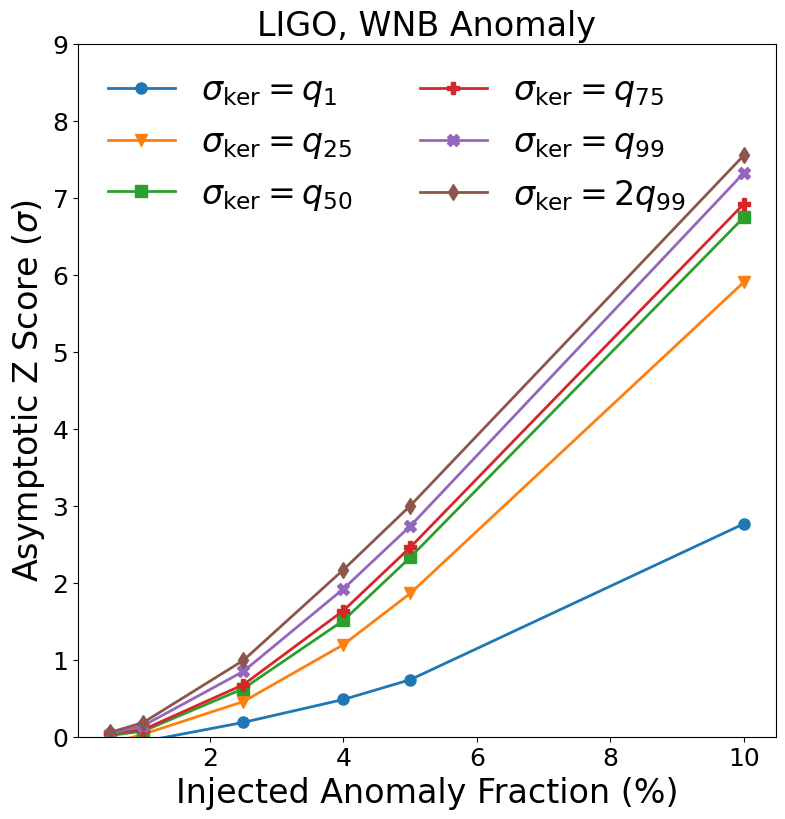

In [3]:
plt.figure(figsize=(9,9))
plt.title(r"LIGO, WNB Anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_obs[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.xscale('log')
xlim = plt.gca().get_xlim()
#plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],lw=2,linestyle='--',color='blue',label='Supervised')
#plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],lw=2,linestyle='--',color='crimson',label='Ideal Supervised')
#plt.xlim(xlim)
#plt.xlim([0.1,1.5])
plt.ylim([0,9])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=24,frameon=False)
plt.savefig("gwak_plots/gwak_asymptoticZscores.pdf",bbox_inches='tight')

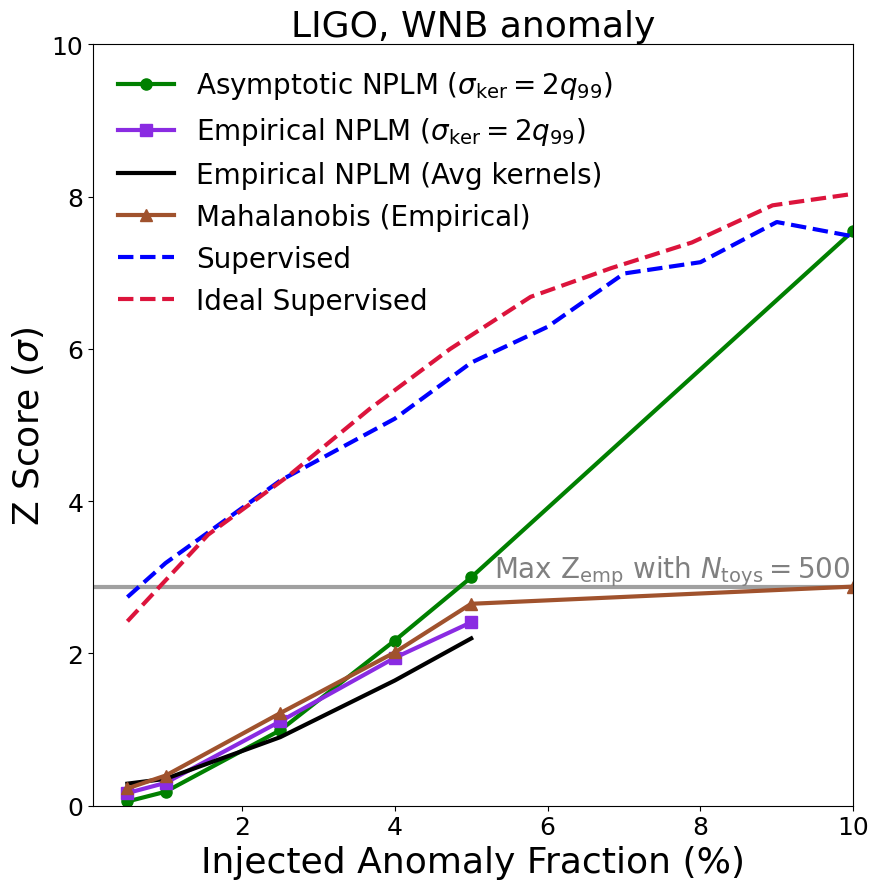

In [4]:
plt.figure(figsize=(9,9))
plt.title(r"LIGO, WNB anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 9.8
isigma = flk_sigmas.index(best_sigma)
handles_1=[]
sigma_label = plotting.kernel_to_label[best_sigma]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
CUTOFF = -1
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:CUTOFF],y_values[:CUTOFF],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# empirical average
CUTOFF = -1
l3,=plt.plot(x_values[:CUTOFF],[z_avg[f] for f in inj_fractions][:CUTOFF],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

plt.xlim(xlim)
plt.xlim([0.05,10])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(5.3,3,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("gwak_plots/LIGO_WNB_Zsummary.pdf",bbox_inches='tight')

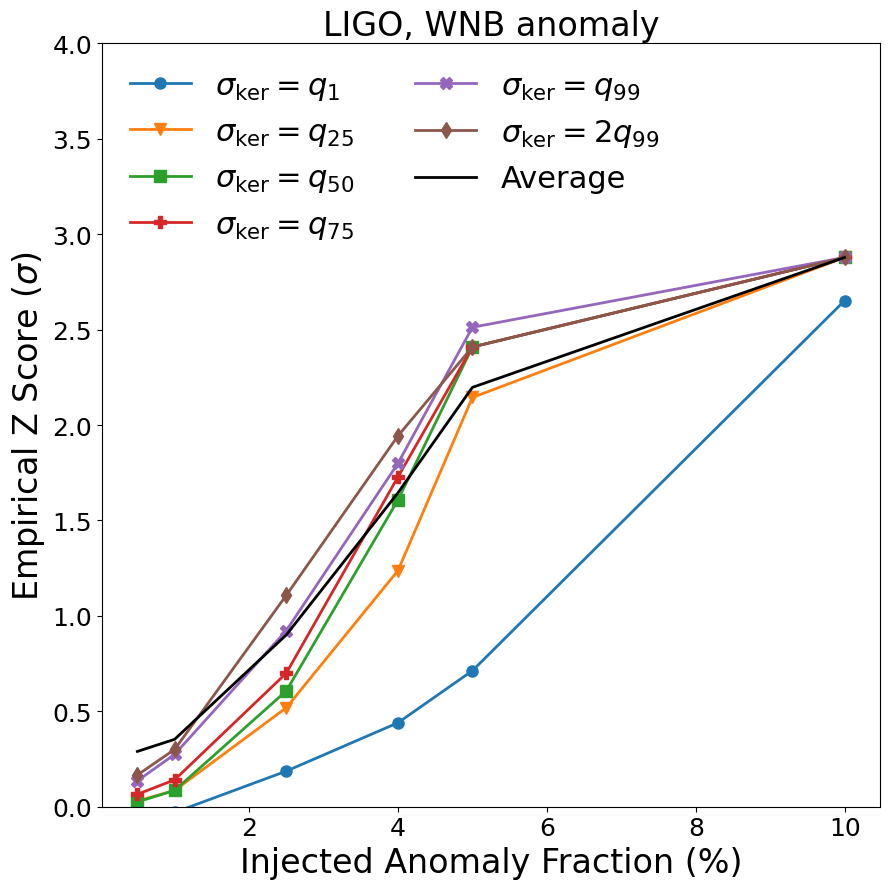

In [7]:
plt.figure(figsize=(9,9))
plt.title(r"LIGO, WNB anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_emp[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.plot(x_values,[z_min[f] for f in inj_fractions],lw=2, marker=None,color="k",label=f"Min Aggregation")
plt.plot(x_values,[z_avg[f] for f in inj_fractions],lw=2, linestyle='-',marker=None,color="k",label=f"Average")
#plt.plot(x_values,[z_prod[f] for f in inj_fractions],lw=2, linestyle='--',marker=None,color="k",label=f"Prod Aggregation")
#plt.xscale('log')
plt.ylim([0,4])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Empirical Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False,loc='upper left')
plt.tight_layout()
plt.savefig("gwak_plots/gwak_empiricalZ.pdf",bbox_inches='tight')

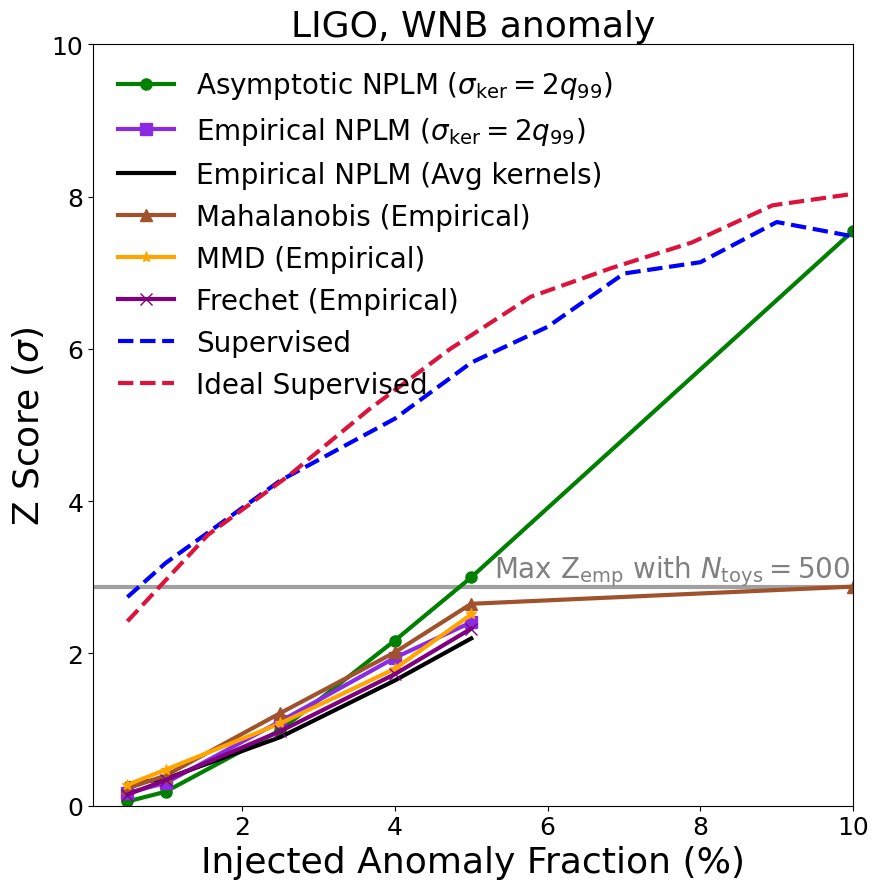

In [9]:
plt.figure(figsize=(9,9))
plt.title(r"LIGO, WNB anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 9.8
isigma = flk_sigmas.index(best_sigma)
handles_1=[]
sigma_label = plotting.kernel_to_label[best_sigma]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
CUTOFF = -1
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:CUTOFF],y_values[:CUTOFF],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# empirical average
CUTOFF = -1
l3,=plt.plot(x_values[:CUTOFF],[z_avg[f] for f in inj_fractions][:CUTOFF],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

# mmd
y_values = [statistics_mmd['z_emp'][f] for f in inj_fractions_mmd]
l8, = plt.plot(100*np.array(inj_fractions_mmd),y_values,lw=3,color='orange',label="MMD (Empirical)",
              marker='*',markersize=8)
handles_1.append(l8)

# Frechet
y_values = [statistics_fid['z_emp'][f] for f in inj_fractions_fid]
l9, = plt.plot(100*np.array(inj_fractions_fid),y_values,lw=3,color='purple',label="Frechet (Empirical)",
              marker='x',markersize=8)
handles_1.append(l9)

xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

plt.xlim(xlim)
plt.xlim([0.05,10])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(5.3,3,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("gwak_plots/LIGO_WNB_Zsummary_withMMDFID.pdf",bbox_inches='tight')